# Create Local Reports  
This notebook generates a PDF report querying data from the FloodNet API,  MyCoast and Open Data NYC 311. Run through the steps to create the reports. A few libraries are installed at the begining, it might take a minute.

- Choose parameteres (NTA, start date, end date)
- Set Up
- Acquire Data
- Create Plots
- Acquire Images and comments from MyCoast
- Generate PDF  

Easiest way to run this report is by going to `Runtime > Run all`.



In [1]:
print("Start")

Start


In [2]:
# @title Input fields
import pandas as pd
sensor_metadata_link = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vRTWu90DyHtzrCfIcM3AkQBZ6zg8ZidiYODkHQx6Q2Jh8aArmQradNlb2evbFL9qUNFi7fXt76qiu3k/pub?gid=1899415071&single=true&output=tsv'
mapbox_url = "https://api.mapbox.com/styles/v1/cankadir/clplqlyio001o01qmewg54ov3/tiles/256/{z}/{x}/{y}@2x?access_token=pk.eyJ1IjoiY2Fua2FkaXIiLCJhIjoiY2pteXplNnEzMHF3YTNrcGx0dGd4MmJrdiJ9.zbhQ39YIdfZufTljuTSl1w"

report_nta = 'New Dorp Midland Beach' # @param ["Arverne-Edgemere", "Howard Beach-Lindenwood" , "Red Hook-Park Slope-Carroll Gardens", "City Island", "Canarsie", "Coney Island-Brighton Beach", "Flushing-Murray Hill-Whitestone", "Williamsburg-Greenpoint", "South Jamaica", "Queens Village-Bellerose-Rosedale", "New Dorp Midland Beach", "Soundview", "Jackson Heights-East Elmhurst"]
start_date = '2021-12-10' # @param {type:"date"}
end_date = '2026-05-01' # @param {type:"date"}

start_date = pd.to_datetime( start_date )
end_date = pd.to_datetime( end_date )

print(report_nta )
print( start_date , end_date )

New Dorp Midland Beach
2021-12-10 00:00:00 2026-05-01 00:00:00


## Detect Floods  
Looking at overall data, list the flood events availalbe per neighborhood. Use a filter for start and end dates and some filter for filtering very small flood event.  
Here I am using `mins_above_4in`, but can be duration and max_depth combination as well.

In [3]:
query_date_start = "2025-10-01"
query_date_end = "2026-03-01"
mins_above_4in = 10

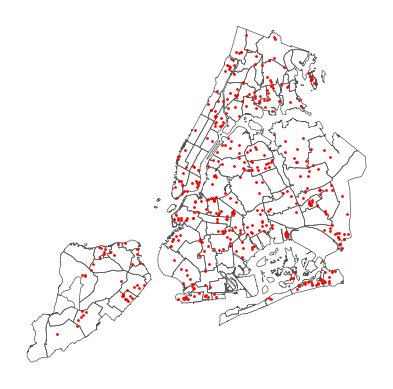

In [4]:
import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Data Paths
sensor_list_url = "https://data.cityofnewyork.us/resource/kb2e-tjy3.json"
measured_events_url = "https://data.cityofnewyork.us/resource/aq7i-eu5q.json"
nta_path = "https://raw.githubusercontent.com/cankadir/FloodAnalysis/main/DATA/report_boundaries_nta_cdta_11-2023.geojson"

# NTAs -> Modified by Sara so coming from our Github not Open Data
ntas = gpd.read_file( nta_path )
ntas = ntas.to_crs(2263) # change crs

# get sensors first
r = requests.get( sensor_list_url )
data = r.json()
sensor_list = pd.DataFrame().from_records( data )
sensor_list = gpd.GeoDataFrame( sensor_list, geometry=gpd.points_from_xy( sensor_list['longitude'], sensor_list['latitude'] ) , crs=4326 )

# plot
fig,ax = plt.subplots()
ntas.plot( ax=ax, fc='none', ec='#555', lw=0.5)
sensor_list.to_crs(2263).plot( ax=ax , markersize=1, color='r' )
ax.axis("off");

In [5]:
measured_events_query = f"{measured_events_url}?\
$where=flood_start_time >= '{query_date_start}T00:00:00' AND flood_start_time < '{query_date_end}T00:00:00'\
AND duration_above_4_inches_mins > {mins_above_4in}"

r = requests.get( measured_events_query )
data = r.json()
flood_list = pd.DataFrame().from_records( data )
print( flood_list.shape[0] , "floods in the data for give params")
flood_list.head(3)

138 floods in the data for give params


,sensor_name,sensor_id,flood_start_time,flood_end_time,max_depth_inches,onset_time_mins,drain_time_mins,duration_mins,duration_above_4_inches_mins,duration_above_12_inches_mins,duration_above_24_inches_mins,flood_profile_depth_inches,flood_profile_time_secs
0,BX - Ditmars St/Hunter Ave 2,BX-ditmars-st-hunter-ave-1kwrk0,2025-10-11T17:40:10.000,2025-10-11T20:51:52.000,6.73,141.03,50.67,191.7,140.2,0,0,"[0.00, 1.26, 1.26, 1.61, 1.89, 2.01, 2.01, 2.1...","[0, 253, 317, 443, 506, 570, 633, 695, 821, 94..."
1,BK - Wallabout St/Throop Ave,BK-wallabout-st-throop-ave-19qu40,2025-10-30T19:04:45.000,2025-10-30T20:34:13.000,18.11,25.26,64.19,89.45,80.67,58.16,0,"[0.00, 2.20, 2.20, 3.50, 4.96, 8.03, 10.08, 10...","[0, 63, 126, 190, 252, 379, 443, 506, 569, 694..."
2,Q - Beach 84 St,Q-beach-84-st-0me680,2025-12-27T04:46:32.000,2025-12-27T07:24:32.000,4.57,106.01,52,158,42.41,0,0,"[0.00, 0.83, 1.06, 1.14, 1.18, 1.34, 1.38, 1.4...","[0, 61, 120, 181, 240, 300, 360, 420, 481, 540..."


In [6]:
flood_list_wlocs = flood_list.join( sensor_list[['sensor_id','geometry']].set_index('sensor_id'), on="sensor_id" )
flood_list_wlocs = gpd.GeoDataFrame( flood_list_wlocs, geometry='geometry', crs=4326 )
flood_list_wlocs = gpd.sjoin( flood_list_wlocs.to_crs(2263), ntas , how='left', predicate='within')

flood_list_wlocs.head(3)

,sensor_name,sensor_id,flood_start_time,flood_end_time,max_depth_inches,onset_time_mins,drain_time_mins,duration_mins,duration_above_4_inches_mins,duration_above_12_inches_mins,...,CountyFIPS,CDTA2020,CDTAName,CDTAType,NTA2020,NTAName,NTAAbbrev,NTAType,report_name,labels
0,BX - Ditmars St/Hunter Ave 2,BX-ditmars-st-hunter-ave-1kwrk0,2025-10-11T17:40:10.000,2025-10-11T20:51:52.000,6.73,141.03,50.67,191.7,140.2,0,...,005,BX10,BX10 Co-op City-Throgs Neck (CD 10 Approximation),0,BX1003,Pelham Bay-Country Club-City Island,PlhmBy,0,City Island,City Island
1,BK - Wallabout St/Throop Ave,BK-wallabout-st-throop-ave-19qu40,2025-10-30T19:04:45.000,2025-10-30T20:34:13.000,18.11,25.26,64.19,89.45,80.67,58.16,...,047,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),0,None,None,None,None,Williamsburg-Greenpoint,Williamsburg-Greenpoint
2,Q - Beach 84 St,Q-beach-84-st-0me680,2025-12-27T04:46:32.000,2025-12-27T07:24:32.000,4.57,106.01,52,158,42.41,0,...,081,QN14,QN14 The Rockaways (CD 14 Approximation),0,QN1402,Rockaway Beach-Arverne-Edgemere,RckwyBch,0,Rockaway Beach-Arverne-Edgemere,Arverne-Edgemere


In [7]:
flood_byNta = flood_list_wlocs.groupby('report_name').agg({
    "sensor_name": list,
    "max_depth_inches": list,
    "flood_start_time": list,
    "flood_end_time": list,
    "duration_mins": list
})

print( f'Floods availalbe from {query_date_start} to {query_date_end}')
for i,r in flood_byNta.iterrows():
    num_floods = len(r['max_depth_inches'])
    print( f"{i} had {num_floods} floods" )

    for i in range(num_floods):
        print(f"     Event {i+1}: {pd.to_datetime(r['flood_start_time'][i]).strftime("%m/%d/%y")}")
        print( f"           Sensor: {r['sensor_name'][i]}")
        print( f"           Duration: {r['duration_mins'][i]} mins" )
        print( f"           Max Depth: {r['max_depth_inches'][i]} inches" )

Floods availalbe from 2025-10-01 to 2026-03-01
Astoria-Queensbridge had 2 floods
     Event 1: 10/30/25
           Sensor: Q - 31st Ave/ 32nd St
           Duration: 83.99 mins
           Max Depth: 11.54 inches
     Event 2: 10/30/25
           Sensor: Q - 10th St/ Vernon Blvd
           Duration: 57 mins
           Max Depth: 9.88 inches
Auburndale-Bayside-Douglaston had 4 floods
     Event 1: 10/30/25
           Sensor: Q - Bell Blvd / Northern Blvd
           Duration: 57 mins
           Max Depth: 11.06 inches
     Event 2: 10/30/25
           Sensor: Q - 188th St/ 58th Ave
           Duration: 32 mins
           Max Depth: 9.21 inches
     Event 3: 10/30/25
           Sensor: Q - 56th Ave/ Springfield Blvd
           Duration: 218.98 mins
           Max Depth: 21.93 inches
     Event 4: 10/30/25
           Sensor: Q - 192nd St/ 39th Ave
           Duration: 23 mins
           Max Depth: 6.22 inches
Bedford-Stuyvesant (West) had 2 floods
     Event 1: 10/30/25
           Sensor: B

In [17]:
flood_byNta['num_floods'] = [len(r) for i,r in flood_byNta['max_depth_inches'].items()]
flood_byNta[['num_floods']].sort_values(by='num_floods', ascending=False)

,num_floods
report_name,
Rockaway Beach-Arverne-Edgemere,35
Queens Village-Bellerose-Rosedale,17
City Island,11
Howard Beach-Spring Creek Park-Lindenwood,9
Williamsburg-Greenpoint,8
Broad Channel,4
Auburndale-Bayside-Douglaston,4
Jamaica,3
Flatbush-Midwood,3


In [18]:
selected_nta = "Rockaway Beach-Arverne-Edgemere"
filtered_floods = flood_list_wlocs[ flood_list_wlocs['report_name'] == selected_nta ].copy()
filtered_floods.head()

,sensor_name,sensor_id,flood_start_time,flood_end_time,max_depth_inches,onset_time_mins,drain_time_mins,duration_mins,duration_above_4_inches_mins,duration_above_12_inches_mins,...,CountyFIPS,CDTA2020,CDTAName,CDTAType,NTA2020,NTAName,NTAAbbrev,NTAType,report_name,labels
2,Q - Beach 84 St,Q-beach-84-st-0me680,2025-12-27T04:46:32.000,2025-12-27T07:24:32.000,4.57,106.01,52,158,42.41,0,...,081,QN14,QN14 The Rockaways (CD 14 Approximation),0,QN1402,Rockaway Beach-Arverne-Edgemere,RckwyBch,0,Rockaway Beach-Arverne-Edgemere,Arverne-Edgemere
4,Q - Beach 84 St,Q-beach-84-st-0me680,2025-10-30T17:26:06.000,2025-10-30T22:33:05.000,19.37,144,162.97,306.98,211.33,94.02,...,081,QN14,QN14 The Rockaways (CD 14 Approximation),0,QN1402,Rockaway Beach-Arverne-Edgemere,RckwyBch,0,Rockaway Beach-Arverne-Edgemere,Arverne-Edgemere
10,Q - Beach 72nd St/Almeda Ave,Q-beach-72nd-st-almeda-ave-1a5hw0,2025-10-30T19:44:42.000,2025-10-30T21:46:53.000,6.57,31.69,90.5,122.19,56.7,0,...,081,QN14,QN14 The Rockaways (CD 14 Approximation),0,QN1402,Rockaway Beach-Arverne-Edgemere,RckwyBch,0,Rockaway Beach-Arverne-Edgemere,Arverne-Edgemere
14,Q - Beach 84 St (2),Q-beach-84th-st-beach-channel-dr-2nf0xc,2025-11-08T13:42:59.000,2025-11-08T16:00:59.000,4.53,72,66,138,47.13,0,...,081,QN14,QN14 The Rockaways (CD 14 Approximation),0,QN1402,Rockaway Beach-Arverne-Edgemere,RckwyBch,0,Rockaway Beach-Arverne-Edgemere,Arverne-Edgemere
28,Q - Beach 84 St,Q-beach-84-st-0me680,2025-11-08T13:29:44.000,2025-11-08T16:01:44.000,4.49,85.01,66.99,152,47.8,0,...,081,QN14,QN14 The Rockaways (CD 14 Approximation),0,QN1402,Rockaway Beach-Arverne-Edgemere,RckwyBch,0,Rockaway Beach-Arverne-Edgemere,Arverne-Edgemere


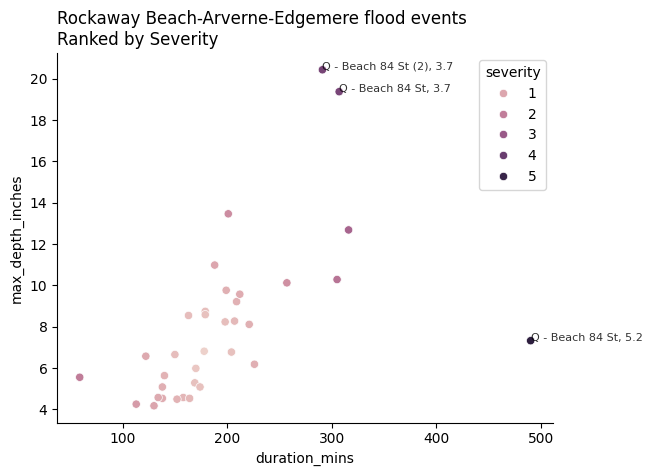

In [32]:
import seaborn as sns

convert_cols = ['duration_mins','max_depth_inches'] 
for i in convert_cols:
    filtered_floods[i] = filtered_floods[i].astype(float)

from sklearn.preprocessing import RobustScaler
# For both columns at once
cols = ['duration_mins', 'max_depth_inches']
filtered_floods[['duration_scaled', 'depth_scaled']] = RobustScaler().fit_transform(
    filtered_floods[cols]
)

# euclidian distance measure on 2-dimensions
filtered_floods['severity'] = (
    filtered_floods['duration_scaled']**2 +
    filtered_floods['depth_scaled']**2
) ** 0.5

fig,ax = plt.subplots()
sns.scatterplot(
    data = filtered_floods,
    x = 'duration_mins',
    y = 'max_depth_inches',
    hue='severity',
    ax=ax
)
ax.set_title(f"{selected_nta} flood events\nRanked by Severity", loc='left')

high_severity = filtered_floods[filtered_floods['severity'] > 3]
for _, row in high_severity.iterrows():
    ax.annotate(
        f"{row['sensor_name']}, {round(row['severity'],1)}",  # or sensor_id
        (row['duration_mins'], row['max_depth_inches']),
        fontsize=8,
        alpha=0.8
    )

sns.despine( ax=ax )

## Set Up  
Prepare the local environment. This process take a few minutes.   
- Install missing libraries
- Install font (Source Sans)
- Create the folder structure html reads from

In [3]:
# %%capture
# print( "Starting Installs" )
# # Install missing libraries
# !pip install contextily
# !pip install weasyprint
# !pip install adjustText

# print("Installing Fonts")
# # Make sure the /contents is empty
# !rm -rf *
# # Download Source Sans 3
# !wget https://github.com/adobe-fonts/source-sans/raw/release/TTF/SourceSans3-Regular.ttf
# !wget https://github.com/adobe-fonts/source-sans/raw/release/TTF/SourceSans3-Bold.ttf

# Make a directory in the fonts folder for source
# Move the fonts file to the directory
# Update fonts cache
# !mkdir -p /usr/share/fonts/truetype/source
# !mv SourceSans3-Regular.ttf /usr/share/fonts/truetype/source
# !mv SourceSans3-Bold.ttf /usr/share/fonts/truetype/source
# !fc-cache -fv

print( 'Create charts folder' )
# Create visuals folder
# !mkdir -p /content/charts
visuals_folder = r"C:\Git_Repo\FloodAnalysis\auto-reports\content\charts"

print( 'Installation as complete\nWe are ready to go!')

Create charts folder
Installation as complete
We are ready to go!


In [5]:
import seaborn as sns
import geopandas as gpd
import contextily as ctx
import requests
import colour
import weasyprint
import matplotlib.font_manager as font_manager
import geocoder
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import dates as mdates

dpi=300
blue = '#007acc'
light_blue = '#39A1FF'

# font_files = font_manager.findSystemFonts(fontpaths='/usr/share/fonts/' )
# for font_file in font_files: font_manager.fontManager.addfont(font_file)

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# mpl.rcParams['font.family'] = 'Source Sans 3'
# mpl.rcParams['font.weight'] = 'regular'

pd.set_option('display.max_columns', None)

print( "Set up complete" )

Set up complete


## Get Data  
If there are any errors (arrow turning red) please let me know, the problem is most probably external, we can let FloodNet team or MyCoast team know.
1. Boundaries (from Can's github)
1. Flood Net Sensors (sensors, events, depths)
2. 311 data
3. MyCoast data

In [6]:
# Find Senors in the Selected NTA
nta_path = "https://raw.githubusercontent.com/cankadir/FloodAnalysis/main/DATA/report_boundaries_nta_cdta_11-2023.geojson"
ntas = gpd.read_file( nta_path , crs=2263)
selected_nta = ntas[ ntas['labels'] == report_nta ]
selected_nta

C:\Users\cansu\AppData\Roaming\Python\Python312\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver GeoJSON does not support open option CRS
  return ogr_read(


,BoroCode,BoroName,CountyFIPS,CDTA2020,CDTAName,CDTAType,NTA2020,NTAName,NTAAbbrev,NTAType,report_name,labels,geometry
7,5,Staten Island,085,SI02,SI02 Mid-Island (CD 2 Approximation),None,SI0202,New Dorp-Midland Beach,NwDrp_MBch,0,New Dorp Midland Beach,New Dorp Midland Beach,"MULTIPOLYGON (((-8246115.017 4950321.306, -824..."


### Join Data to Sensor Locations


In [ ]:
URL = "https://api.floodnet.nyc/v1/graphql"

def get_sensor_locations():
  result = requests.post(URL, json={
      'query': '''
    query {
      deployments(where: {deploy_type: {_in: ["pluvial", "coastal"]}}) {
        name           # The name of the sensor. e.g.
        deployment_id  # Our unique ID to identify a sensor
        location       # Where the sensor is located
        date_deployed  # When was the sensor deployed?
        date_down      # was the sensor taken down?
        deploy_type    # pluvial, coastal, tidal, or weather
      }
    }
    '''
    }).json()

  # Turn the response into a table
  deployments = pd.DataFrame(result['data']['deployments'])
  deployments = deployments.dropna(subset=['location'])

  # parse dates
  deployments['date_deployed'] = pd.to_datetime(deployments.date_deployed, format='ISO8601')
  deployments['date_down'] = pd.to_datetime(deployments.date_down, format='ISO8601')
  deployments['coordinates'] = [np.array(x['coordinates'][::-1]) for x in deployments.location]
  deployments['lat'] = deployments['coordinates'].str[0]
  deployments['lon'] = deployments['coordinates'].str[1]
  deployments = deployments.drop( ['location','coordinates'], axis = 1)
  deployments = gpd.GeoDataFrame( data = deployments , geometry=gpd.points_from_xy(deployments['lon'],deployments['lat'], crs=4326) )
  return deployments

sensors = get_sensor_locations()
sensors.head(3)

In [ ]:
nta_sensors = gpd.sjoin( sensors , ntas.to_crs(4326) )
filtered_sensors = nta_sensors[ nta_sensors['labels'] == report_nta ].copy()
filtered_sensors = filtered_sensors[ ~filtered_sensors['name'].str.contains('RETIRED') ]
filtered_sensors = filtered_sensors[ ~filtered_sensors['name'].str.contains('openweathermap.org') ]
filtered_sensors = filtered_sensors[ ~filtered_sensors['name'].str.contains('weather station') ]

filtered_sensors['name'].values

### Get sensor events between start time and end time.


In [ ]:
def get_events( start_date, end_date, sensors ):
  print( start_date, end_date, sensors )
  start_time_strf = start_date.strftime("%Y-%m-%d")
  end_time_strf = end_date.strftime("%Y-%m-%d")

  results = requests.post(URL, json={
      'query': '''
    query Events($deployment_ids: [String!], $label: [String!], $start_time: timestamp, $end_time: timestamp) {
      sensor_events(where: {start_time: {_gte: $start_time, _lte: $end_time}, label:{_in: $label}, deployment_id: {_in: $deployment_ids}}) {
        id
        start_time
        end_time
        label
        annotated_by
        deployment_id
        deployment {
          name
          location
          date_deployed
          date_down
          deploy_type
        }
      }
    }
    ''',
      'variables': {
          "deployment_ids": list(sensors),
          "start_time": f"{start_time_strf}",
          "end_time": f"{end_time_strf}",
          "label": ["flood"]
      }
  }).json()

  events = pd.DataFrame(results['data']['sensor_events'])
  events = events[events.end_time.notna()]
  return events

print( start_date , end_date )
events = get_events( start_date, end_date , filtered_sensors['deployment_id'].values )
print( events.shape[0] , 'events detected' )
events.head()

### Get Raw Data

In [ ]:
def get_depth_data( sensor_id , event_start, event_end ):
  result = requests.post(URL, json={
          'query': '''
    query TimeSeriesData($deployment_ids: [String!]!, $start_time: timestamptz!, $end_time: timestamptz!, $min_depth: Int ) {
        depth_data(where: {
          deployment_id: { _in: $deployment_ids },
          time: { _gt: $start_time, _lt: $end_time },
          depth_proc_mm: { _gt: $min_depth },
        }, order_by: {time: asc}) {
          time
          depth_proc_mm
          deployment_id
        }
    }
      ''',
          'variables': {
              'deployment_ids': [sensor_id],
              'start_time': event_start,
              'end_time': event_end,
              'min_depth': 0
          },
      }).json()

  data_df = pd.DataFrame(result['data']['depth_data'])
  return data_df

buffer = 1
events['start_time_buffered'] = pd.to_datetime(events['start_time'] , format='mixed' ) - pd.Timedelta(hours=buffer)
events['end_time_buffered'] = pd.to_datetime(events['end_time'] , format='mixed' ) + pd.Timedelta(hours=buffer)

data_df = pd.DataFrame()
for i,r in events.iterrows():
  t = get_depth_data( r['deployment_id'] , r['start_time_buffered'].strftime("%Y-%m-%d %H:%M:00") , r['end_time_buffered'].strftime("%Y-%m-%d %H:%M:00") )
  data_df = pd.concat( [data_df , t] )

del(t)

print( data_df.shape[0] , "rows")

data_df['time'] = pd.to_datetime( data_df['time'] , format='ISO8601' )
data_df = data_df.sort_values( by=['deployment_id','time'] )
data_df.head()

### Get 311 DATA  
311 data starts from the end date of the query and goes back 3 years.  
Do we want to update this to the first reported data?


In [ ]:
polygon = selected_nta.dissolve().to_crs(4326)
polygon.geometry = polygon.geometry.simplify(0.001).buffer( 0.002 ).simplify(0.001)

def get_311_data( polygon , start_date ):
    '''Query 311 data for the selected CDTA'''
    data_query = 'https://data.cityofnewyork.us/resource/erm2-nwe9.json'
    # Add more descriptors here
    descriptors = ['Street Flooding (SJ)','Catch Basin Clogged/Flooding (Use Comments) (SC)', 'Manhole Overflow (Use Comments) (SA1)' ]
    descriptors_filter = ' OR '.join([f"descriptor='{d}'" for d in descriptors])
    selectors = 'unique_key,created_date,agency,complaint_type,descriptor,status,latitude,longitude'

    start_date = end_date - pd.Timedelta(days=360*3)
    # start_date to the beginning of the year
    start_date = start_date.replace(month=1,day=1).date().strftime('%Y-%m-%d')

    polygon_geom = polygon.geometry.values[0]

    url = f"{data_query}?$where=within_polygon(location, '{polygon_geom}') AND created_date>'{start_date}' AND ({descriptors_filter})&$select={selectors}&$limit=5000"
    # print( url )
    response = requests.get(url)
    if response.status_code != 200:
        print(f"Error {response.status_code}")
    else:
        data_311 = pd.DataFrame( response.json() )
    data_311 = gpd.GeoDataFrame(data_311.drop(['latitude','longitude'],axis=1), geometry=gpd.points_from_xy(data_311.longitude, data_311.latitude), crs=4326 )
    return data_311

data_311 = get_311_data( polygon, start_date )
print( data_311.shape[0] , "rows in 311 data" )
data_311.head(3)

### Get MyCoast Data

In [ ]:
def get_myCoast_data():

    db_len = 1000
    paged_data = pd.DataFrame()
    count = 1
    while db_len > 998:
      url = f'https://mycoast.org/blueurchin-js/arcgis/can-ny.php?page={count}'

      headers = { 'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:109.0) Gecko/20100101 Firefox/116.0'}
      response = requests.get(url, headers=headers )
      data = response.json()

      data = pd.DataFrame( data['features'] )
      db_len = data.shape[0]
      print( db_len )
      data['coords'] = data['geometry'].apply( lambda x: x['coordinates'])
      data['lon'] = data['coords'].str[0]
      data['lat'] = data['coords'].str[1]
      data['picUrl'] = data['properties'].apply( lambda x: x['picUrl'])
      data['comment'] = data['properties'].apply( lambda x: x['comment'])
      data['photo_date'] = data['properties'].apply( lambda x: x['photo_date'])
      data['photo_time'] = data['properties'].apply( lambda x: x['photo_time'])
      data['id'] = data['properties'].apply( lambda x: x['id'])
      data['datetime'] = pd.to_datetime( data['photo_date'] + " " + data['photo_time'] , format='mixed' )
      data = data.drop( ['geometry','properties','coords','photo_date','photo_time','type'], axis=1 )
      data = gpd.GeoDataFrame( data=data , geometry=gpd.points_from_xy(data['lon'],data['lat']), crs=4326 )
      paged_data = pd.concat( [paged_data , data] )
      count = count + 1

    return paged_data

myCoast_data = get_myCoast_data()
myCoast_data.head()

## GENERATE PLOTS  
All charts and maps that will be used in the report will be generated here. The resulting charts are not shown but are stored in `/content/charts/`. If you click on the folders sign to the left and go into charts folder, you can double-click on the images to view them.  
- Main map
- Inset map
- 311 heatmap
- Flooded days timeline
- Zoom-in events


### Map 1
- Countains:
  - Flood sensor locations
  -  frequency of days with floods  
  - 311 locations
- Annotations are positioned automatically
- Many complex symbology is generated in layers.  
- Produces **map1.png**

In [ ]:
def create_local_data(df):
  local_data = df.copy()
  local_data['clean_depth_in'] = local_data['depth_proc_mm'] / 25.4
  local_data['time_NY'] = local_data['time'].dt.tz_convert('America/New_York').dt.tz_localize(None)
  local_data = local_data.join( sensors[['deployment_id','name','lat','lon']].set_index('deployment_id') , on='deployment_id', how='left')
  local_data['sensor_display_name'] = local_data['name'].str.split(" - ").str[1].str.strip()
  return local_data

local_data = create_local_data( data_df )

# Get max depth for each deployment per day
daily_max_flood = local_data.groupby( ['deployment_id', pd.Grouper(key='time_NY', freq='1d')] ).agg({'clean_depth_in':'max' }).reset_index()

#Count Flooded Days
flooded_days = daily_max_flood.groupby('deployment_id').size().reset_index().rename(columns={0:'flooded_days'})

# First date sensor recorded data, this will be the annotation
first_record = local_data.groupby('deployment_id').agg({'time_NY':'min','sensor_display_name':'first'})

# Join Data
flooded_days_map = local_data.groupby('deployment_id').agg({'lat':'first','lon':'first'}).join( flooded_days.set_index('deployment_id') ).join( first_record )
flooded_days_map['time_NY'] = flooded_days_map['time_NY'].dt.strftime('%Y-%m-%d')

# GeoDataFrame
flooded_days_map = gpd.GeoDataFrame(flooded_days_map, geometry=gpd.points_from_xy(flooded_days_map.lon, flooded_days_map.lat), crs=4326).to_crs(3857)

# Calculate # of flood events
num_flood_events = events.groupby('deployment_id',as_index=False).size().rename(columns={'size':'num_flood_events'})
flooded_days_map = flooded_days_map.join( num_flood_events.set_index('deployment_id') )

flooded_days_map.head()

In [ ]:
import matplotlib.patheffects as pe
from adjustText import adjust_text
import matplotlib

local_cdta = ntas[ntas['labels'] == report_nta ].to_crs(3857)
other_cdta = ntas[ntas['labels'] != report_nta ].to_crs(3857)

def plot_map1():
    fig,ax = plt.subplots( figsize=(5.225,4.5), dpi=dpi )

    # 1. ---------------  BOUNDARIES ------------------
    local_cdta.plot( ax=ax , fc = 'none' , ec = light_blue, alpha = 0.8 , zorder = 10 )
    other_cdta.plot( ax=ax , fc = 'white' , ec = 'none', alpha = 0.5, zorder = 10 )

    # ZOOM and SIZE ADJUSTMENT
    # Define plot bounds by local cdta + padding
    pad = 100
    ax.set_xlim( local_cdta['geometry'].bounds.minx.values[0]-pad , local_cdta['geometry'].bounds.maxx.values[0]+pad )
    ax.set_ylim( local_cdta['geometry'].bounds.miny.values[0]-pad , local_cdta['geometry'].bounds.maxy.values[0]+pad )

    # is x or y bounds larger?
    x_size = abs( (local_cdta['geometry'].bounds.minx.values[0]-pad) - (local_cdta['geometry'].bounds.maxx.values[0]+pad) )
    y_size = abs( (local_cdta['geometry'].bounds.miny.values[0]-pad) - (local_cdta['geometry'].bounds.maxy.values[0]+pad) )
    if x_size > y_size:
        ratio = 5.225 / 4.5
        y_mid = ( local_cdta['geometry'].bounds.miny.values[0] + local_cdta['geometry'].bounds.maxy.values[0] ) / 2
        y_pad = ( x_size / ratio ) / 2
        ax.set_ylim( y_mid - y_pad , y_mid + y_pad )
    else:
        ratio = 4.5 / 5.225
        x_mid = ( local_cdta['geometry'].bounds.minx.values[0] + local_cdta['geometry'].bounds.maxx.values[0] ) / 2
        x_pad = ( y_size / ratio ) / 2
        ax.set_xlim( x_mid - x_pad , x_mid + x_pad )

    # Sensors with Flooding
    with_flooding = flooded_days_map[ flooded_days_map['flooded_days'].notnull() ]

    # 2. ------------- WITH FLOODING --------------
    # 2a. BLUE CIRCLE
    t = sns.scatterplot(
        x = with_flooding.geometry.x, y = with_flooding.geometry.y,
        ax = ax,
        facecolor = "#057de4", edgecolor = 'black',
        linewidth = 0.25,
        size = with_flooding[ 'flooded_days' ], sizes = ( 40 , 250 ),
        alpha = 0.9, zorder = 12,
    )

    # 2b. BLACK DOT
    flooded_days_map.plot( ax=ax, markersize = 6 , fc = 'black' , ec = 'none' , alpha = 1 , zorder = 13 )
    # 311 orange points
    data_311.to_crs(3857).plot( ax=ax , fc = '#fe4c0c' , ec = 'none', alpha = 0.5 , zorder = 2 , markersize=6 )

    # Plot myCoast
    myCoast_localdata = myCoast_data.sjoin( local_cdta.to_crs(4326) )
    myCoast_localdata = myCoast_localdata.drop_duplicates(subset=['lat','lon'])
    if myCoast_localdata.shape[0] > 0:
      myCoast_localdata.to_crs( 3857 ).plot( ax=ax , fc = "#d966ff", ec='k', lw=0.25, alpha=0.9 , markersize= 9, zorder=3)

    # 2c. Annotations
    texts = with_flooding.apply(
        lambda x: ax.annotate(
            text = f"{x['sensor_display_name']}:\n{int(x['num_flood_events']) } floods\nsince {pd.to_datetime(x['time_NY']).strftime('%b. %Y')}",
            xy = ( x.geometry.x , x.geometry.y ) ,
            ha = 'center' , va = 'bottom' ,
            xycoords = 'data' ,
            fontsize = 8.5, fontweight='bold' , color = '#057de4', zorder=100 ,
            path_effects=[pe.withStroke(linewidth=1.5, foreground="w")]),
        axis = 1
    )

    # 3. ------------- NO FLOODING --------------
    no_flooding = flooded_days_map[ flooded_days_map['flooded_days'].isnull() ]
    if no_flooding.shape[0] > 0:
        t2 = no_flooding.plot( ax=ax, markersize=50, fc='none', ec='black', lw=0.5 , zorder=10 )
    else:
        t2 = None

    no_events = filtered_sensors[ ~filtered_sensors['deployment_id'].isin( flooded_days_map.index ) ]
    if no_events.shape[0] > 0:
        print( no_events.shape[0] , "sensors with no events")
        no_events.to_crs(3857).plot( ax=ax, markersize=50, fc='none', ec='black', lw=0.5 , zorder=10 )

    # Plot Parks
    all_parks = gpd.read_file( 'https://raw.githubusercontent.com/cankadir/FloodAnalysis/main/DATA/NYC_Parks_Simplified_FIlled.geojson' , crs=4326 )
    all_parks = all_parks.to_crs(3857)
    all_parks.plot( ax=ax , fc = '#d4f28d' , ec = 'none', alpha = 0.5 , zorder = 2 )

    # Adjust Text so they are not intersecting
    exp_val = 1.25
    adjust_text(
        texts = texts.tolist(),
        ax=ax,
        avoid_self=True,
        x = with_flooding.geometry.x, y = with_flooding.geometry.y,
        expand = ( exp_val,exp_val ),
        force_text=(0.25,0.25),
        ensure_inside_axes = True,
        iter_lim = 4000,
        arrowprops=dict(arrowstyle="-", color="#057de4" , lw=0.5) )

    ctx.add_basemap( ax, source = mapbox_url, attribution="" )

    ax.axis('off')
    ax.legend([], frameon=False)
    plt.tight_layout(pad=0)
    plt.savefig( map1_path , dpi = dpi , bbox_inches='tight' ,transparent="True", pad_inches=0)
    plt.close()

map1_path = os.path.join( visuals_folder , "map1.png" )
plot_map1()
print( f"Map Plotted, check {visuals_folder}map1.png")


### Map 2: NYC Inset Map
This is a very simple map of sensor locations.

In [ ]:
def plot_insetMap():
    fig,ax = plt.subplots(figsize=(2.475,2.475), dpi=dpi)

    projected_cdta = ntas.dissolve().to_crs(3857)
    local_cdta.to_crs(3857).plot(ax=ax , fc='none' , ec=blue, lw=0.2 )
    sensors.to_crs(3857).plot( ax=ax , fc = blue , ec = 'w', alpha = 0.9 , markersize = 3, lw=0.1 )

    # Define plot bounds by local cdta + padding
    pad = 1000
    ax.set_xlim( projected_cdta['geometry'].bounds.minx.values[0]-pad , projected_cdta['geometry'].bounds.maxx.values[0]+pad )
    ax.set_ylim( projected_cdta['geometry'].bounds.miny.values[0]-pad , projected_cdta['geometry'].bounds.maxy.values[0]+pad )

    ctx.add_basemap( ax, source= mapbox_url, attribution="" )
    ax.axis('off')

    ax.annotate( 'Flood Sensor Locations', xy=( ax.get_xlim()[0]+1000, ax.get_ylim()[1]-1000 ) , ha='left', va='top', fontsize=9, fontweight='bold', color='black' , zorder=100 )

    fig.tight_layout(pad=0)
    fig.savefig( insetmap_path , dpi = dpi, bbox_inches='tight' ,transparent="True", pad_inches=0)
    plt.close()

insetmap_path = os.path.join( visuals_folder , "insetmap.png" )
plot_insetMap()

print( f"Map Plotted, check {insetmap_path}")

### 311 Heatmap
This is the chart at the bottom of page 2.  
Blue gradient is the flooded days count per month  
Orange gradient is the number of 311 requests per month.  

The legend items for the charts are generated separatly but with in this block

In [ ]:
year_now = pd.Timestamp.now().year
year_past = year_now - 3

year_list = list(range( year_past +1 , year_now+1 , 1))
year_list

In [ ]:
# Get 3 tears of data based on events for all the sensors
all_events = get_events(
    sensors= filtered_sensors['deployment_id'].values,
    start_date = pd.to_datetime(f"{year_list[0]}-01-01"),
    end_date = pd.to_datetime(f"{year_list[-1]}-12-31") )

print( all_events.shape[0] , 'events detected' )
display( all_events.head(3) )

all_depths = pd.DataFrame()
for i,e in all_events.iterrows():
    if (i%100==0) and (i!=0): print( i , 'events processed')

    temp = get_depth_data(
        sensor_id = e['deployment_id'],
        event_start = pd.to_datetime(e['start_time']).floor('1min').strftime("%Y-%m-%d %H:%M"),
        event_end = pd.to_datetime(e['end_time']).ceil('1min').strftime("%Y-%m-%d %H:%M") )

    all_depths = pd.concat( [all_depths , temp] )

all_depths['time_NY'] = pd.to_datetime(all_depths['time'], format='mixed').dt.tz_convert('America/New_York').dt.tz_localize(None)
all_depths = all_depths.join( sensors[['deployment_id','name','lat','lon']].set_index('deployment_id') , on='deployment_id', how='left')
all_depths['sensor_display_name'] = all_depths['name'].str.split(" - ").str[1].str.strip()
all_depths['clean_depth_in'] = all_depths['depth_proc_mm'] / 25.4
all_depths.head(3)

In [ ]:
# Segmented Color Map
def make_Ramp( ramp_colors ):
    from colour import Color
    # from matplotlib.colors import LinearSegmentedColormap
    from matplotlib.colors import ListedColormap, LinearSegmentedColormap

    color_ramp = ListedColormap( ramp_colors )
    return color_ramp

def prepare_data( filtered_local_data ):
    f = '1MS'

    # Daily max value per sensor
    sensors_over_time = filtered_local_data.groupby( ['sensor_display_name', pd.Grouper(key='time_NY', freq='1D')] ).agg({'clean_depth_in':'max'}).reset_index()

    # Number of days with flooding per month, only when the days are there
    sensors_over_time = sensors_over_time.groupby( ['sensor_display_name', pd.Grouper(key='time_NY', freq=f)] ).agg({'clean_depth_in':'count'}).reset_index()

    # Create an empty list of months (from first day) to join the previous flooded days counts
    all_months = pd.DataFrame( index = pd.date_range( filtered_local_data['time_NY'].dt.round("1d").min() , filtered_local_data['time_NY'].max() , freq=f ) ).reset_index().rename(columns={'index':'time_NY'} )
    all_months['sensor_display_name'] = [filtered_local_data['sensor_display_name'].unique()] * all_months.shape[0]
    all_months = all_months.explode('sensor_display_name')
    all_months['time_NY'] = all_months['time_NY'].dt.round("1d")

    t = all_months.join( sensors_over_time.set_index(['sensor_display_name','time_NY']), on=['sensor_display_name','time_NY'] )

    pt = t.pivot( index='sensor_display_name', columns='time_NY', values='clean_depth_in' )
    # if pt with 0 only after the recorded value per row
    for i,r in pt.iterrows():
        cols = pt.columns
        has_started = False
        for c in cols:
            if not pd.isna(r[c]):  has_started = True
            if has_started:
                if pd.isna(r[c]) :
                    pt.loc[i,c] = 0

    data_311['created_date'] = pd.to_datetime(data_311['created_date'])
    filtered_311 = data_311[ data_311['created_date'] < filtered_local_data['time_NY'].max() ]

    monthly_311 = filtered_311.groupby( pd.Grouper(key='created_date', freq=f) ).agg({'unique_key':'nunique'}).reset_index().rename(columns={'unique_key':'count'})
    monthly_311['ind'] = '311 Complaints'
    monthly_311 = monthly_311.pivot( index='ind', columns='created_date', values='count' )

    # join and drop to equalize the ranges
    pt = pd.concat( [pt,monthly_311] ).drop( index="311 Complaints" )
    pt.index = [i.split(' - ')[1] if '-' in i else i for i in pt.index ]

    return pt, monthly_311

custom_ramp = make_Ramp( ['#EFF0F0' ,"#ABDAEF","#58B4ED", '#0586CE', '#045B9B'] )
pt, monthly_311 = prepare_data( all_depths )

def plot_heatmap():

    values = ['No Flood', 'Minimal Flooding', 'Minor Flood', 'Moderate Flooding', 'Major Flooding']
    fig, axs = plt.subplots( nrows = 2 , figsize=(7.7,3), height_ratios=[pt.shape[0],1] , sharex=True , dpi=dpi )

    # ------------------ Flood VIZ ------------------
    ax = axs[0]
    sns.heatmap( pt, ax=ax, cmap= custom_ramp, cbar=False, lw=1, linecolor='w' )

    ax.tick_params( axis='x', which='both', bottom=False, top=False, labelbottom=False )
    ax.tick_params( axis='y', which='both', left=False , labelsize=9, pad=0.1 )
    ax.set_ylabel('')
    ax.set_xlabel('')

    [ ax.axhline( i+0.495 , color='#333' , lw=0.25 ) for i in ax.get_yticks()]

    # draw frame
    ax.axhline( 0, color='#333', lw=1 )
    ax.axvline( 0, color='#333', lw=1 )
    ax.axvline( ax.get_xticks()[-1]+0.5 , color='#333', lw=1 )

    # ----------------- 311 VIZ -----------------
    ax = axs[1]
    sns.heatmap(
        monthly_311, ax=ax,
        cmap= 'OrRd', cbar=False,
        lw=1, linecolor='w',
    )

    ax.tick_params( axis='y', which='both', left=False, rotation=0 , labelsize=9, pad=0.1 )
    ax.tick_params( axis='x', which='both', bottom=False , pad=0.1 )

    ax.set_ylabel('')
    ax.set_xlabel('')

    # draw frame
    ax.axhline( 0, color='#333', lw=1 )
    ax.axhline( 1, color='#333', lw=1 )
    ax.axvline( 0, color='#333', lw=1 )
    ax.axvline( ax.get_xticks()[-1]+0.5 , color='#333', lw=1 )

    # x-ticks
    ax.set_xticks( np.arange( 0.5 , ax.get_xticks()[-1] , 4 ) )
    xticklabels = [ pd.to_datetime(x.get_text()).strftime('%b') if pd.to_datetime(x.get_text()).strftime('%b') != 'Jan' else f"{pd.to_datetime(x.get_text()).strftime('%b')}\n{pd.to_datetime(x.get_text()).strftime('%Y')}"  for x in ax.get_xticklabels() ]
    ax.set_xticklabels( xticklabels , rotation=0 , ha='left', va='top' , fontsize=8 )
    ax.set_yticklabels( ['311 Complaints'], color='#Ef2700' )

    [ axs[1].axvline(ticks-0.5, color='#333', lw=0.5 ) for labels,ticks in zip(ax.get_xticklabels(),ax.get_xticks()) if "Jan" in labels.get_text() ]
    [ axs[0].axvline(ticks-0.5, color='#333', lw=0.5 ) for labels,ticks in zip(ax.get_xticklabels(),ax.get_xticks()) if "Jan" in labels.get_text() ]

    ax.set_xlim( ax.get_xlim()[0] , ax.get_xlim()[1]+0.05 )
    plt.tight_layout( h_pad=0.025 )
    plt.savefig( heatmap_path , bbox_inches='tight' ,transparent=False, pad_inches=0, dpi=dpi)
    plt.close()
heatmap_path = os.path.join( visuals_folder , "heatmap_311.png" )
plot_heatmap()
print( f"311 Heatmap is Plotted, it is here {heatmap_path}")


#### Custom Legends

In [ ]:
def flooded_days_legend( path ):
    max_flooded_day = pt.max().max()
    fake_data = pd.DataFrame( np.linspace(  max_flooded_day,0, 3 ) )
    fake_data = pd.concat( [fake_data, pd.DataFrame([None]) ] )

    fig,ax = plt.subplots( figsize=(0.5,1), dpi=dpi )

    sns.heatmap(
        fake_data,ax=ax,
        cmap = custom_ramp, cbar = False,
        lw = 1, linecolor = 'w',
    )

    ax.tick_params( axis='x', which='both', bottom=False, top=False, labelbottom=False )
    ax.tick_params( axis='y', which='both', left=False, labelleft=False, labelright=True , labelsize=9, pad=0.1, rotation=0 )
    ax.set_yticklabels( [ f"{int(max_flooded_day)} Floods", f"{int(max_flooded_day/2)} Floods", "No floods", "No data" ])

    fig.tight_layout( pad=0 )
    fig.savefig( path , bbox_inches='tight' ,transparent="True", pad_inches=0, dpi=dpi )
    plt.close()

def legend_311( path ):
    max_complaint = monthly_311.max().max()
    fake_data = pd.DataFrame( np.linspace(  max_complaint , 0, 4 ) )

    fig,ax = plt.subplots( figsize=(0.5,1), dpi=dpi )

    sns.heatmap(
        data = fake_data, ax=ax,
        cmap = 'OrRd' , cbar = False,
        lw = 1, linecolor = 'w'
    )

    ax.tick_params( axis='x', which='both', bottom=False, top=False, labelbottom=False )
    ax.tick_params( axis='y', which='both', left=False, labelleft=False, labelright=True , labelsize=9, pad=0.1, rotation=0 )
    ax.set_yticklabels( [str(int(i)) for i in np.linspace(  max_complaint , 0 , 4 )]  )

    fig.tight_layout( pad=0 )
    fig.savefig( path , bbox_inches='tight' ,transparent="True", pad_inches=0, dpi=dpi )
    plt.close()

# Flood legend
legend_floods_path = os.path.join( visuals_folder , "legend_floods.png" )
flooded_days_legend(legend_floods_path)

# 311 legend
legend_311_path = os.path.join( visuals_folder , "legend_311.png" )
legend_311(legend_311_path);

### Flooded Days  
We use data from `sensors list metadata` to find out what to hightlight.  
Metadata is stored on the drive folder [here](https://docs.google.com/spreadsheets/d/1LA17hb-oD7wxpPPIiKw6ywPNO3yWygklLwSEh-FXETM/edit?usp=drive_link).

In [ ]:
sensor_metadata = pd.read_csv( sensor_metadata_link , sep='\t')
sensor_metadata = sensor_metadata[ sensor_metadata['Highlighted event name'].notnull() ]
highlighted_sensor = sensor_metadata[ sensor_metadata['neighborhood_label'] == report_nta ]

flood_type = highlighted_sensor['Event type'].values[0]

event_startdate = highlighted_sensor['Highlighted Event Start'].values[0]
event_startdate = pd.to_datetime( event_startdate )

event_enddate = highlighted_sensor['Highlighted Event End'].values[0]
event_enddate = pd.to_datetime( event_enddate )

display( highlighted_sensor )
print( event_startdate , event_enddate )

In [ ]:
hili_depths = all_depths[ all_depths['deployment_id'] == highlighted_sensor['deployment_id'].values[0] ]

In [ ]:
# Filter data to the selected Sensor
single_sensor = hili_depths.copy()
single_sensor['clean_depth_in'] = single_sensor['depth_proc_mm'] / 25.4
single_sensor['time_NY'] = pd.to_datetime(single_sensor['time'], format='mixed').dt.tz_convert('America/New_York').dt.tz_localize(None)

f = '1D'
single_sensor_1h = single_sensor.groupby(pd.Grouper(key='time_NY', freq=f)).agg({'clean_depth_in':'max'}).reset_index()
single_sensor_1h['date'] = single_sensor_1h['time_NY'].dt.date
single_sensor_1h['hour'] = single_sensor_1h['time_NY'].dt.hour
single_sensor_1h['year'] = single_sensor_1h['time_NY'].dt.year

# Febraury 29th causes a problem. Move one day to the left.
single_sensor_1h['flat_date'] = single_sensor_1h['time_NY'].apply( lambda x: pd.to_datetime(x).strftime('1900-%m-%d %H:%M:%S') if pd.to_datetime(x).strftime('%m-%d') != "02-29" else (pd.to_datetime(x) - pd.Timedelta('1D')).strftime('1900-%m-%d %H:%M:%S') )
single_sensor_1h['flat_date'] = pd.to_datetime( single_sensor_1h['flat_date'], format='mixed' )
single_sensor_1h['flat_date_end'] = single_sensor_1h['flat_date'] + pd.Timedelta( f )

grid_colors = ['#ca6702','#bb3e03','#ae2012']
values = ['Minor Flood', 'Moderate Flood', 'Major Flood']

last_day = hili_depths['time_NY'].max().round('1d')

def plot_timeline():

  fig,axs = plt.subplots( nrows = len(year_list) , sharex=True, sharey=True, figsize = (5,2.75) )
  for i,year in enumerate( year_list ):
      ax = axs[i]
      single_sensor_1h_year = single_sensor_1h[ single_sensor_1h['year'] == year ]

      if single_sensor_1h_year.shape[0] > 0:
        # lollipop stems
        ax.vlines( ymax=single_sensor_1h_year['clean_depth_in'], ymin=0, x=single_sensor_1h_year['flat_date'] , alpha=1 , lw=1, color='#39a1ff' )

        # lollipop heads
        single_sensor_1h_year_above = single_sensor_1h_year[ single_sensor_1h_year['clean_depth_in'] > 0 ]
        ax.scatter( y=single_sensor_1h_year_above['clean_depth_in'], x=single_sensor_1h_year_above['flat_date'], s=10 , marker='o' ,fc='#39a1ff' , ec='none', zorder=5 )

        ax.hlines(
            y=0,
            xmin=single_sensor_1h_year['flat_date'].min(),
            xmax = single_sensor_1h_year['flat_date'].max()
            )

        # grey span at start
        if single_sensor_1h_year['flat_date'].min() - pd.to_datetime(f'01-01-1900 00:00') > pd.Timedelta('1 days'):
          ax.axvspan(
              xmin = pd.to_datetime(f'01-01-1900 00:00'),
              xmax = single_sensor_1h_year['flat_date'].min(),
              color='#cecece', alpha=0.5, zorder=1
          )

        if pd.to_datetime(f'12-31-1900 23:59') - single_sensor_1h_year['flat_date'].max() > pd.Timedelta('1 days'):
          ax.axvspan(
              xmin = single_sensor_1h_year['flat_date'].max(),
              xmax = pd.to_datetime(f'12-31-1900 23:59'),
              color='#cecece', alpha=0.5, zorder=1
          )

      else:
        ax.axvspan( xmin=pd.to_datetime(f'01-01-1900 00:00'), xmax=pd.to_datetime(f'12-31-1900 23:59') , color='#cecece', alpha=0.5, zorder=1)

      sns.despine( ax=ax, bottom=True, right=False )
      ax.set_ylim( 0, np.where( single_sensor_1h['clean_depth_in'].max() > 8, single_sensor_1h['clean_depth_in'].max() + 6, 14 ) )
      ax.set_ylabel( year, rotation=0 , labelpad=3, fontsize = 9 , ha='right', va='center' )

      # format y-axis as %b %d
      ax.xaxis.set_major_formatter( mdates.DateFormatter('%b') )
      # every month
      ax.xaxis.set_major_locator( mdates.MonthLocator() )

      ax.set_xlim( pd.to_datetime('24-12-1899 00:00:00',dayfirst=True) , pd.to_datetime('05-01-1901 23:59:59',dayfirst=True) )
      ax.tick_params(axis='y', which='both', left=False, labelleft=False )
      ax.tick_params( axis='x' , labelsize=8 , bottom=False )

      # Horizontal grid (2 12 24  )
      [ ax.axhline(t, ls='--', lw=0.4, alpha=0.8, color=grid_colors[n]) for n,t in enumerate([4,12,24]) ]
      [ ax.annotate(f'{t}"', xy=( pd.to_datetime('01-01-1900')+pd.Timedelta(days=10),t) ,color=grid_colors[n], va='bottom', ha='right', fontsize=7 ) for n,t in enumerate([4,12,24]) ]
      # grid
      [ ax.axvline( pd.to_datetime( f'{i}-01-1900' ), color="#cecece", lw=0.25, alpha=1 ) for i in range(1,13)]


      # set spine lw
      ax.spines['left'].set_linewidth(0.5)
      ax.spines['right'].set_linewidth(0.5)

      if i==0:
          ax.spines['top'].set_visible(True)
          ax.spines['top'].set_linewidth(0.5)
      if i==len(axs)-1:
          ax.spines['bottom'].set_visible(True)
          ax.spines['bottom'].set_linewidth(0.5)

      # Highlighted Event Box
      event_startdate = pd.to_datetime( highlighted_sensor['Highlighted Event Start'].values[0] ).tz_convert('America/New_York').tz_localize(None)
      event_enddate = pd.to_datetime( highlighted_sensor['Highlighted Event End'].values[0] ).tz_convert('America/New_York').tz_localize(None)

      if year == event_startdate.year :

          print( event_startdate , event_enddate )
          event_converted_startdate = pd.to_datetime( f'1900-{event_startdate.month}-{event_startdate.day} {event_startdate.hour}:00:00' )
          event_converted_enddate = pd.to_datetime( f'1900-{event_enddate.month}-{event_enddate.day} {event_enddate.hour}:00:00' )

          event_midpoint = event_converted_startdate + ( event_converted_enddate - event_converted_startdate ) / 2

          event_converted_startdate = event_midpoint - pd.Timedelta( days = 4.5 )
          event_converted_enddate = event_midpoint + pd.Timedelta( days = 4.5 )

          # make span with vmin and vmax
          ax.fill_between( [ event_converted_startdate , event_converted_enddate ] , 0 , single_sensor_1h['clean_depth_in'].max() + 3 , ec='#ff7f0e', fc='none', alpha=1 , zorder=150, capstyle='round', joinstyle='round' )

  fig.tight_layout( w_pad=0.005, h_pad=0.25 )
  flood_timeline_path = os.path.join( visuals_folder , "flood_timeline.png" )
  fig.savefig( flood_timeline_path , transparent="True" , bbox_inches='tight', pad_inches=0.02 , dpi=dpi )
  plt.close()
  return flood_timeline_path

flood_timeline_path = plot_timeline()
print( f"Timeline plotted, check: {flood_timeline_path}")

### Zoom-In Chart
This chart overlaps:
1. Sensor readings  
1a. Hightlight
2. Rainfall OR Tide
3. The rainboot (at 16")  

Since non of these items are in the same data space, this chart uses 3 axis.
Make sure the measurements look reasonable

#### Download Tide Data  
We are re-downloading the data for this one event with better buffers are without filtering non-zero values to be able to show start and end.  

**Open Weather** data will be added here.

In [ ]:
# Needed query setup
time_pad = 1
buffered_start = event_startdate - pd.Timedelta(hours=time_pad)
buffered_end = event_enddate + pd.Timedelta(hours=time_pad)
event_sensor = highlighted_sensor['deployment_id'].values[0]
print( event_startdate , event_enddate )
print( buffered_start , buffered_end )

In [ ]:
def request_tidedata( event_start, event_end, tidal_gauge ):
    result = requests.post(URL, json={
        'query': '''
            query TideData($dev_id: String!, $start_time: timestamptz!, $end_time: timestamptz!) {
                tidal_data(where: {
                    dev_id: {_eq: $dev_id},
                    time: {
                        _gt: $start_time,
                        _lt: $end_time,
                    },
                }) {
                    time
                    dev_id
                    navd88_mm
                    mllw_mm
                    mhhw_mm
                }
            }
            ''',
            'variables': {
                'dev_id': tidal_gauge,
                'start_time': event_start.isoformat(),
                'end_time': event_end.isoformat(),
            },
    })

    data = result.json()['data']['tidal_data']
    data = pd.DataFrame(data)
    data['time'] = pd.to_datetime(data['time'])
    data = data.sort_values('time')
    return data

def adjust_tidedata( event_start, event_end, tidal_gauge ):
    delta_time = (event_end - event_start).total_seconds() / 360
    print( delta_time )
    if delta_time < 1000:
        data = request_tidedata( event_start, event_end, tidal_gauge )
    else:
        intervals = pd.date_range( event_start, event_end, freq='4D')
        data = pd.DataFrame()
        for i in range( len(intervals) - 1 ):
            data = pd.concat( [data, request_tidedata( intervals[i], intervals[i+1], tidal_gauge )] )

    gr = data.groupby( pd.Grouper(key='time', freq='18min') ).agg({'mhhw_mm': 'mean'} ).reset_index()

    return gr

def get_precipitation( buffered_start, buffered_end , sensor_name ):

  sensor_name = 'nyc-micronet-bknyrd'
  sensor_name = sensor_name.split('-')[-1]
  print( sensor_name)

  import io
  import requests

  buffered_start = buffered_start.isoformat().replace( "+00:00" , "Z")
  buffered_end = buffered_end.isoformat().replace( "+00:00" , "Z")

  timerange = f"{buffered_start}/{buffered_end}"
  payload = "variables[]=precip:incremental@mm&variables[]=precip@mm&variables[]=precip_max_intensity@mm/min"
  url = f'https://api.nysmesonet.org/data/dynserv/coned/5min/nyc/{timerange}?{payload}'

  data = requests.get( url )
  df = pd.read_csv( io.StringIO( data.content.decode('utf-8') ) , sep="," , parse_dates=['datetime'])
  df = df[ df['station'] == sensor_name.upper() ].copy()
  df['time_NY'] = df['datetime'].dt.tz_convert('America/New_York').dt.tz_localize(None)
  df['precip_max_intensity [in/min]'] = 0.03937008 * df['precip_max_intensity [mm/min]']
  df['precip_max_intensity [ft/min]'] = 0.00328084 * df['precip_max_intensity [mm/min]']
  return df

background_data = pd.DataFrame()

if (flood_type == "Coastal") or (flood_type == "Tidal"):
  tidal_gauge = highlighted_sensor.iloc[0]['tidal_gauge']

  background_data = adjust_tidedata( buffered_start, buffered_end , tidal_gauge )
  background_data['time'] = pd.to_datetime( background_data['time'] )
  background_data['time_NY'] = background_data['time'].dt.tz_convert('America/New_York').dt.tz_localize(None)
  background_data['mhhw_ft'] = background_data['mhhw_mm'] * 0.00328084
if flood_type == 'Pluvial':
  print( "Pluvial")
  station = highlighted_sensor.iloc[0]['weather_station']
  background_data = get_precipitation( buffered_start, buffered_end , station )

background_data.head()

In [ ]:
dd = get_depth_data(
    sensor_id = highlighted_sensor['deployment_id'].values[0],
    event_start = (event_startdate - pd.Timedelta( hours = time_pad)).strftime("%Y-%m-%d %H:%M"),
    event_end = (event_enddate + pd.Timedelta( hours = time_pad )).strftime("%Y-%m-%d %H:%M") )

dd['time_NY'] = pd.to_datetime(dd['time'], format='mixed').dt.tz_convert('America/New_York').dt.tz_localize(None)
dd['clean_depth_in'] = dd['depth_proc_mm'] / 25.4
dd.head()

#### Plot zoom-in Chart

In [ ]:
event_startdate_ny = event_startdate.tz_convert("America/New_York").tz_localize(None)
event_enddate_ny = event_enddate.tz_convert("America/New_York").tz_localize(None)

event_location = highlighted_sensor['sensor_display_name'].str.split(" - ").str[1].values[0]
event_name = highlighted_sensor['Highlighted event name'].values[0]
event_date = pd.to_datetime(highlighted_sensor['Highlighted Event Start'].values[0]).strftime('%b %d, %Y')

delta_hours = (event_enddate_ny - event_startdate_ny).total_seconds() / 3600

grid_colors = ['#ca6702','#bb3e03','#ae2012']
fig,ax = plt.subplots( figsize=(5,1.5) , dpi=dpi )

# ---- Plot FLOOD ----
def plot_flood( filtered_data ):

    ax.plot( filtered_data['time_NY'], filtered_data['clean_depth_in'], lw=2.5, color='#2093f2' , label='Flooding' )
    ax.fill_between( filtered_data['time_NY'], filtered_data['clean_depth_in'], color="#92d0f7", alpha=0.9 )

    # if the max flood dept is smaller than 14, push the chart to be atleast 20"
    ax.set_ylim( -0.3 , 20 if dd['clean_depth_in'].max() < 20 else dd['clean_depth_in'].max()+6 )

    # hlines on x ticks similar to grid
    [ ax.axvline( t , color='#333', lw=0.35, ls=":", zorder = 14 ) for t in ax.get_xticks() ]
    [ ax.axhline(t, ls='--', lw=0.5, alpha=0.8, color=grid_colors[n] , zorder=11) for n,t in enumerate([4,12,24])  ]
    [ ax.annotate(f'{t}"', xy=( event_startdate_ny - pd.Timedelta(hours=time_pad) , t) ,color=grid_colors[n], va='bottom', ha='left', fontsize=8 , zorder=11 ) for n,t in enumerate([4,12,24]) ]

    # Styling
    sns.despine(left=False, ax=ax )
    ax.tick_params(axis='y', which='both', left=True, labelleft=True , labelsize=8 , pad=0.5, color='#2093f2' )
    ax.tick_params( axis='x', labelsize=8 , pad=0.5, bottom=False )
    ax.set_yticklabels( [f'{i:.0f}"' for i in ax.get_yticks()] , color='#2093f2' )
    ax.set_ylabel('Flood Depth (in)', fontsize=6, labelpad=0.5, color='#2093f2')
    ax.set_title( f"{event_date} - {event_location}, {event_name}" , fontsize=9 , color='#2093f2', loc='left' , ha='left', fontweight='bold' )

    # Common Styling
    ax.xaxis.set_major_locator( mdates.HourLocator(interval= 1 if delta_hours < 12 else 2) )
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%I%p'))
    ax.set_xlim( [event_startdate_ny - pd.Timedelta(minutes=10) , event_enddate_ny + pd.Timedelta(minutes=10)] )

plot_flood( dd )

# ---- PLOT BACKGROUND DATA ----
def plot_bgdata():
    if flood_type == 'Pluvial':

        # background_data_filtered = background_data[ (background_data['time_NY'] >= event_startdate_ny ) & (background_data['time_NY'] <= event_enddate_ny ) ]
        ax2.bar( background_data['time_NY'], background_data['precip_max_intensity [in/min]'] , width=0.0015 , fc='#676767', ec='none', alpha=0.56 , label='5min Precipitaion (in/min)' )

        # only focus on the event time
        ax2.set_xlim( event_startdate_ny , event_enddate_ny )

        # # add " to highset y-tick
        ax2.set_ylim( 0 , 0.1 if background_data[ 'precip_max_intensity [in/min]' ].max() < 0.1 else background_data[ 'precip_max_intensity [in/min]' ].max() * 1.2 )
        ax2.set_yticks( ax2.get_yticks() , labels=[f"{i:.2f}\"" for i in ax2.get_yticks()] )
        ax2.set_ylabel( "Rainfall Intensity (in/min)" , fontsize=6, labelpad=0.8, color='#333' )

    if (flood_type == 'Coastal') or (flood_type == 'Tidal'):

        ax2.plot( background_data['time_NY'], background_data['mhhw_ft'] , color='#555', lw=0.5 , ls="--" ,alpha=0.9 , label='Tide levels' )
        ax2.set_ylim( np.floor(background_data['mhhw_ft'].min() * 1.2) , np.ceil(background_data['mhhw_ft'].max() * 1.2) )
        ax2.set_ylabel('Tide Level - mhhw (ft)', rotation=90 , labelpad=3, fontsize = 6 )

    # spines and styling
    for i in ['left','top','bottom']: ax2.spines[i].set_visible(False)
    ax2.tick_params(axis='y',which='both',left=False, labelleft=False , labelsize=8 )
    ax2.yaxis.tick_right()
    ax.spines['left'].set_linewidth(0.5)
    ax2.spines['right'].set_linewidth(0.5)
    ax2.set_xlim( [event_startdate_ny - pd.Timedelta(minutes=10) , event_enddate_ny + pd.Timedelta(minutes=10)] )

# do not worry about background data (tide/prcp) if the data does not exist.
if background_data.shape[0] > 0:
  ax2 = ax.twinx()
  ax2.set_zorder(1)
  ax2.set_facecolor("none")
  plot_bgdata()

# ---- Plot RAINBOOT
# Plots the rainboot to axin axes
height_ratio = 16 / (ax.get_ylim()[1] - ax.get_ylim()[0])
axin = ax.inset_axes( [0.005 , 0 , 0.2 , height_ratio ]  , zorder=100)    # create new inset axes in data coordinates

def plot_rainboot():
    # A new axis is formed -> height of the axis is plot height / flood height, to match 16
    import matplotlib.image as mpimg
    img_id = '1zja2MnKBovz7WLrKfCSM0Wau5C5QL_aW'
    img_link = f'https://drive.google.com/uc?export=view&id={img_id}'

    img_data = requests.get(img_link).content
    with open('rainboot.png', 'wb') as handler:
        handler.write(img_data)

    rainboot = mpimg.imread('rainboot.png')

    axin.imshow( rainboot )
    axin.axis('off')

plot_rainboot()

# ---- Plot 16" Rainboot Annotation
axrb = ax.inset_axes( [0 , 0 , 1 , 1 ]  , zorder=41 )    # create new inset axes in data coordinates
axrb.annotate( '16" Rainboot' , xy=( 0.03 , height_ratio + 0.01 ), xycoords='axes fraction' , ha='left', va='bottom', fontsize=8 , color='#FF7C1A' )
axrb.axis('off')

# -- -- -- -- Order plots  -- -- -- --
ax.set_zorder(2)
ax.set_facecolor("none")
axin.set_zorder(40)
axin.set_facecolor("none")
axrb.set_zorder(45)
axrb.set_facecolor("none")

# ---- SAVE ----
popup_chart_path = os.path.join( visuals_folder , "flood_timeline_zoom.png" )
print( f"Zoom-In chart is saved at {popup_chart_path}")

fig.savefig( popup_chart_path ,bbox_inches='tight', transparent="True" , pad_inches=0 , dpi=dpi )
plt.close();

## PHOTOS FROM MYCOASTS  
Paginate myCoast REST until you reach a page with less than 1000 enteries.

### How are the images choosen?  
- Add a 1/4 mile buffer to the sensor location until 50 photos are found.
- Try to choose only images with comments. If there are more then a few images with comments, prioritize them first.
- From the remainder choose 2 random images

In [ ]:
# check if myCoast_photos folder exists in the visual folder
if not os.path.exists( os.path.join( visuals_folder , 'myCoast_photos' ) ): os.makedirs( os.path.join( visuals_folder , 'myCoast_photos' ) )
photos_folder = os.path.join( visuals_folder , 'myCoast_photos' )

myCoast_data = myCoast_data[ myCoast_data['picUrl'] != False ]
print( myCoast_data.shape[0] )
myCoast_data.head()

In [ ]:
dist = 0.5
myCoast_photos_count = 0

local_cdta = ntas[ntas['labels'] == report_nta ].to_crs(3857)
other_cdta = ntas[ntas['labels'] != report_nta ].to_crs(3857)

# Grow the search radius until we have at least 10 pictures.
while myCoast_photos_count < 30 :
    dist = dist + 0.15
    local_cdta['buffer_geometry'] = local_cdta['geometry'].to_crs(2263).buffer( 5280*dist ).to_crs(4326)
    buffer_cdta = local_cdta.set_geometry( 'buffer_geometry' )

    myCoast_cdta = myCoast_data.sjoin( buffer_cdta )
    myCoast_photos_count = myCoast_cdta.shape[0]

# i need 4 pictures, preferably with comments
myCoast_cdta = myCoast_cdta.sort_values( by='datetime' )
myCoast_cdta_wcomments = myCoast_cdta[ ~myCoast_cdta['comment'].isin(['','0',0]) ]
print( myCoast_cdta.shape[0],'images', "\n" , myCoast_cdta_wcomments.shape[0] ,'images with comments' )

display( myCoast_cdta_wcomments.head() )

In [ ]:
if dist < 1:
  photo_title = "What does flooding look like in your neighborhood?"
else:
  photo_title = "What does similar flooding look like in New York City?"

In [ ]:
import matplotlib.image as mpimg

if myCoast_cdta_wcomments.shape[0] > 2:
  myCoast_selection = myCoast_cdta_wcomments.sample(2)
else:
  myCoast_selection = pd.concat([
      myCoast_cdta_wcomments,
      myCoast_cdta.sample(2-myCoast_cdta_wcomments.shape[0])
  ])

img_urls = myCoast_selection['picUrl'].values
print( img_urls )

In [ ]:
def reverse_geocode(lat,lon):
    # use arcgis to get the address
    g = geocoder.arcgis( [lat,lon] , method='reverse' )
    address = g.address
    address = " ".join(address.split(' ')[1:])
    address = address.replace( ', New York' ,'' )
    return address

myCoast_selection['address'] = myCoast_selection['geometry'].apply( lambda x: reverse_geocode( x.y, x.x ) )
myCoast_selection['time_formatted'] = myCoast_selection['datetime'].dt.strftime('%b %d, %Y')

myCoast_selection

## View MyCoast Images

In [ ]:
# @markdown Run this cell again to view the **myCoast** Images with comments.
# @markdown
# @markdown This cell, reselectes 2 images from the previous selection and then reverse geocodes the locations using ESRI geocoder.

print( 'delete existing images in the dir' )
!rm -f /content/charts/myCoast_photos/*

import matplotlib.image as mpimg

if myCoast_cdta_wcomments.shape[0] > 2:
  myCoast_selection = myCoast_cdta_wcomments.sample(2)
else:
  myCoast_selection = pd.concat([
      myCoast_cdta_wcomments,
      myCoast_cdta.sample(2-myCoast_cdta_wcomments.shape[0])
  ])

img_urls = myCoast_selection['picUrl'].values

def reverse_geocode(lat,lon):
    # use arcgis to get the address
    g = geocoder.arcgis( [lat,lon] , method='reverse' )
    print( g )
    address = g.address
    address = " ".join(address.split(' ')[1:])
    address = address.replace( ', New York' ,'' )
    return address

print('geocoding')
myCoast_selection['address'] = myCoast_selection['geometry'].apply( lambda x: reverse_geocode( x.y, x.x ) )
myCoast_selection['time_formatted'] = myCoast_selection['datetime'].dt.strftime('%b %d, %Y')

def add_line_breaks(text, n=10):
  # break the long text
  words = text.split()
  new_text = ""
  count = 0

  for word in words:
    new_text += word + " "
    count += 1

    if count == n:
      new_text += "\n"
      count = 0
  return new_text

fig,axs = plt.subplots( ncols=2 )

for count,(i,r) in enumerate(myCoast_selection.iterrows()):
  ax = axs[count]

  url = r['picUrl']
  img_data = requests.get(url).content
  file_name = url.split("/")[-1]
  file_name = f"/content/charts/myCoast_photos/{file_name}"
  with open( file_name , 'wb') as handler: handler.write(img_data)

  img = mpimg.imread( file_name )
  ax.imshow( img )
  ax.axis('off')

  comment = r['comment']
  comment = add_line_breaks( comment, 6 )

  ax.text( s = comment , x=0, y=1 ,transform=ax.transAxes , va='bottom')
  ax.text( s = r['address'] , x=0, y=0 ,transform=ax.transAxes , va='top')


## Create PDF  
Download all necessary content into assets folder and prepare variables.  
Replace variables in HTML, print to index.html, convert to pdf.  
Download PDF, open in browser.


In [ ]:
# prompt: create a folder called assests if it does not exist
!mkdir -p assets

assets = [
    ( '10HQ50cbZl3qcjy-ny9TrHE8fqotwljld' , 'QR_Code-01.jpg' ), #done
    ('1UqR8e1srauJyxa1t6hVNVapbLdc_Ft0j' , 'Map-Legend.svg'),
    # ('16WGHvmFPsXprpnB_oYk9UTdwhMajnQNO' , 'Logos-01.jpg' ),
    ('14lQ2wf2Az45-WX1Je5Y6BguI0QV1RlvZ' , 'Logos-01-bottom.jpg' )
]

def download_asset( url, file_name ):
  url = f'https://drive.google.com/uc?export=view&id={url}'
  img_data = requests.get(url).content

  file_name = f"/content/assets/{file_name}"
  with open( file_name , 'wb') as handler:
      handler.write(img_data)

for id,name in assets:  download_asset( id , name )


In [ ]:
data_through = np.where( end_date.month - 5 < 0 , f"Published with Data Through January {end_date.year}" , f"Published with Data Through May {end_date.year}" )
next_report = np.where( pd.Timestamp.now().month - 5 > 0, f"June {pd.Timestamp.now().year+1}" , f"January {pd.Timestamp.now().year + 1}")
first_data_date = filtered_sensors.sort_values(by='date_deployed')['date_deployed'].iloc[0].strftime("%Y")

print( f"{data_through}" )
print( next_report )

In [ ]:
css = """
  html,body{
      margin:0;
      padding:0;
      width: 100%;
      height: 100%;
      font-family: 'Source Sans 3', sans-serif;
      -moz-box-sizing: border-box;
      -webkit-box-sizing: border-box;
      box-sizing: border-box;
  }

  h1 {
      page-break-before: always;
      margin: 0;
      padding: 0;
  }

  .page{
      width:8.5in;
      height:11in;
      background-color: white;
      -moz-box-sizing: border-box;
      -webkit-box-sizing: border-box;
      box-sizing: border-box;
      padding: 0.4in;
      /* border: 1px solid #000; */
  }

  .divider{
      width: 100%;
      height: 2px;
      background-color: #007acc;
      margin: 0;
      padding: 0;
      border: none;
      margin-bottom: 0.125in;
  }

  #map-left{
      width: 5.225in;
      height: 4.9in;
      float: left;
  }

  #map-right{
      width: 2.475in;
      height: 4.9in;
      float: right;
  }

  .chart-title{
      font-size: 18pt;
      font-weight: bold;
  }

  #map1{
      width: 5.225in;
      height: 4.494in;
      border: #000 solid 1px;
      border-right: none;
  }

  #map-legend{
      width: 2.475in;
      height:2.42in;
      border: #000 solid 1px;
      border-bottom: none;
  }

  #inset-map{
      width: 2.475in;
      height: 2.475in;
      border: #000 solid 1px;
  }

  .flood-watch-block{
      width: 5.07in;
      height: 2.5in;
      margin: 0;
      padding: 0;
      float: left;
  }

  #photo{
      width: 2.475in;
      height: 2.475in;
      background-size: cover;
      background-position: center;
  }

  .comment{
      width: 2.475in;
      color:#007acc;
      font-size: 9pt;
      font-weight: bold;
      font-style: italic;
  }

  .top-left{
      width: 5.1in;
      height: 5.5in;
      float:left;
      margin-right: 0.125in;
  }

  .top-right{
      width: 2.475in;
      height: 5.5in;
      float: right;
  }

  #zoom{
      max-height: 1.5in;
      width: auto;
      margin-top:0.125in
  }

  .highlight{
      color: #007acc;
      font-weight: bold;
  }

  .legend-311{
      width: 7.7in;
      height: 0.75in;
      text-align: right;
      font-size: 9pt;
      margin-top: 0.05in;
  }

  .page-footer {
    position: absolute;
    bottom: 0;
    width: 7.7in;
    height: 0.25in;
    font-size: 8pt;
    border-top: #000 solid 1px;
  }

  .page-num{
      float: right;
      margin-right: 0.05in;
      margin-top: 0.05in;
      font-weight: bold;
      font-size: 9pt;
  }
  """

about_1 = "The maps and charts in this report show the severity, frequency and location of street-level flood events. This report was generated using data from FloodNet sensors, 311 reports, and photos of floods shared through the NYC Community Flood Watch Project using MyCoast NY. It will be updated again in January 2025."
about_2 = "Made by New York Sea Grant & FloodNet NYC, supported by the Alfred P. Sloan Foundation & FEMA’s FY 2022 CTP Program - Region 2, award number EMN-2022-CA-00015. Designed by Studio 2263."

html_template = f"""
  <!DOCTYPE html>
  <html lang="en">
  <head>
      <meta charset="UTF-8">
      <meta name="viewport" content="width=device-width, initial-scale=1.0">
      <title>Document</title>
      <link rel="preconnect" href="https://fonts.googleapis.com">
      <link rel="preconnect" href="https://fonts.gstatic.com" crossorigin>
      <link href="https://fonts.googleapis.com/css2?family=Source+Sans+3:ital,wght@0,400;0,500;0,600;0,700;1,600&display=swap" rel="stylesheet">

      <style>
        {css}
      </style>
  </head>
  <body>
      <!-- Page 1 -->
      <div class="page">
          <!-- Page Title -->
          <div class="title-block">
              <div class="page-subtitle" style="font-size: 12pt;width:7.5in;color: #007acc;">Local flood report for</div>
              <div class="page-title" style="font-size: 24pt;font-weight: bold;width:7.7in;color: #007acc;">{report_nta}</div>
          </div>

          <hr class="divider">

          <!-- MAPS -->
          <div class="map-block" style="width:7.7in; height: 5in;">
              <!-- MAP LEFT -->
              <div id="map-left">
                  <div class="title-block">
                      <div class="chart-title" style="padding-left:0.125in;height: 0.4in; border-top: #000 solid 1px;border-left: #000 solid 1px;">Neighborhood Flood Data</div>
                  </div>
                      <div id="map1" style="background-image:url({map1_path});background-size: cover;background-position: center;background-repeat: no-repeat;" alt="Days Flooded" ></div>
              </div>

              <!-- MAP RIGHT -->
              <div id="map-right">
                  <!-- LEGEND -->
                  <div id="map-legend">
                      <img src="/content/assets/Map-Legend.svg" alt="legend" />
                  </div>

                  <img id="inset-map" src="{insetmap_path}" alt="NYC Sensors" />
              </div>
          </div>

          <!-- FLOOD WATCH -->
          <div class="flood-watch" style="height: 4.2in; margin-top: 0.125in;">
              <div class="title-block">
                  <div class="chart-title" style="height: 0.4in;">{photo_title}</div>
              </div>

              <div class="flood-watch-block">
                  <div id="photo" style="float:left;background-image: url({myCoast_selection['picUrl'].values[0]})"></div>
                  <div id="photo" style="float:right;background-image: url({myCoast_selection['picUrl'].values[1]})"></div>

                  <!-- photo timestamps -->
                  <div class="timestamp" style="float:left;width: 2.475in;height:0.15in;font-size:9pt;color:#676767;overflow: hidden;white-space: nowrap;text-overflow: ellipsis;">{myCoast_selection['time_formatted'].values[0] + " &#9679; " + myCoast_selection['address'].values[0] }</div>
                  <div class="timestamp" style="float:right;width: 2.475in;height:0.15in;font-size:9pt;color:#676767;overflow: hidden;white-space: nowrap;text-overflow: ellipsis;">{myCoast_selection['time_formatted'].values[1] + " &#9679; " + myCoast_selection['address'].values[1] }</div>
              </div>

              <img id="qr-code" style="width:2.475in;float:right; margin-left:0.109in;height:2.497in" src="/content/assets/QR_Code-01.jpg" alt="qr code" />

              <div class="flood-watch-block" style="margin-top: 0.15in; height: 0.85in;">
                      <div class="comment" style="float:left;max-height: 1in;overflow: hidden;">{ myCoast_selection['comment'].values[0] }</div>
                      <div class="comment" style="float:right;max-height: 1in;overflow: hidden;">{ myCoast_selection['comment'].values[1] }</div>
              </div>
          </div>

          <!-- FOOTER -->
          <div class="page-footer">
              <div class="page-num">1</div>
          </div>
      </div>

      <h1></h1>
      <!-- Page 2 -->
      <div class="page">
          <div id="sensor-hili" style="width:7.7in;height: 5.5in;">
              <div class="top-left">
                  <div class="title-block">
                      <div class="page-title" style="font-weight: 400; width:5.1in; font-size: 20pt;color: #007acc;">{data_through}</div>
                      <hr class="divider">
                      <div class="chart-title">{highlighted_sensor['sensor_display_name'].values[0].split(' - ')[1].replace('/',' & ')}: flood detections + depths</div>
                  </div>

                  <div class="chart-block">
                      <img id="chart" src="/content/charts/flood_timeline.png" style="width:100%" alt="chart" />
                      <div id="zoom">
                          <img id="chart" src="/content/charts/flood_timeline_zoom.png" style="width:100%;height: 1.5in;" alt="chart" />
                      </div>
                  </div>
              </div>

              <div class="top-right">
                  <!-- ABOUT THIS REPORT -->
                  <div style="border: #333 1px solid;padding:5px;box-sizing: border-box;">
                    <div style="font-size: 21px;font-weight: bold;margin-top:2.5px">About this Report</div>
                    <div class="about-report" style="font-size:9pt;margin-bottom:5px;">The maps and charts in this report show the severity, frequency and location of street-level flood events. This report was generated using data from FloodNet sensors, 311 reports, and photos of floods shared through the NYC Community Flood Watch Project using MyCoast NY. It will be updated again in {next_report}.</div>
                    <!-- WHO MADE THIS REPORT -->
                    <div class="about-report" style="font-size:9pt;margin-bottom:0px;font-weight: bold;">Who made this report?</div>
                    <div class="about-report" style="font-size:9pt;margin-bottom:5px;">Made by New York Sea Grant & FloodNet NYC, supported by the Alfred P. Sloan Foundation & FEMA’s FY 2022 CTP Program - Region 2, award number EMN-2022-CA-00015. Designed by Studio 2263.</div>
                    <img src="/content/assets/Logos-01-bottom.jpg" alt="" style="height: 1.75in;bottom:0;margin:0;">
                </div>
                <div id="notes" style="font-size: 9pt;padding:5px;box-sizing: border-box;">Since {local_data['time_NY'].min().strftime('%b. %Y')}, when the first neighborhood flood sensor was installed, <span class="highlight">{flooded_days['flooded_days'].sum()} floods</span> have been recorded. The highest water level detected was <span class="highlight">{local_data['clean_depth_in'].max():.1f} inches</span> at {local_data[local_data['clean_depth_in'] == local_data['clean_depth_in'].max()]['sensor_display_name'].values[0].replace('/',' & ')} on {local_data[local_data['clean_depth_in'] == local_data['clean_depth_in'].max()]['time_NY'].dt.strftime('%m/%d/%Y').values[0]}.</div>
              </div>
          </div>

          <div id="threoneone" style="margin-top: 50px;">
              <div class="chart-title">History of neighborhood flood detections + 311 flood complaints</div>

              <div class="legend-311">
                  <div id="legend-311-1" style="float:left; width:2in;height: 0.75in;">
                      <div class="legend-311-title" style="float:left">
                          <div class="legend-311-title-text">{local_data['time_NY'].min().strftime('%m/%d/%Y')} - {last_day.strftime('%m/%d/%Y')}</div>
                      </div>
                  </div>
                  <!-- Flood Heatmap Legend -->
                  <div id="legend-311-2" style="float:left; width:2.68in;height: 0.75in;">
                      <div class="legend-311-title" style="float:left">
                          <div class="legend-311-title-text"><strong>Flood sensor detections</strong></div>
                          <div class="legend-311-title-text">Number detected per month</div>
                      </div>
                      <img src="{ legend_floods_path }" alt="" id="image-311" style="float:left;height: 0.75in;margin-left: 0.125in;">
                  </div>

                  <!-- 311 Heatmap Legend -->
                  <div id="legend-311-3" style="float:right; width:2.68in;height: 0.75in;">
                      <div class="legend-311-title" style="float:left">
                          <div class="legend-311-title-text"><strong>311 flood-related complaints</strong></div>
                          <div class="legend-311-title-text">311 data available at<br>https://opendata.cityofnewyork.us/</div>
                      </div>
                      <img src="{ legend_311_path }" alt="" id="image-311" style="float:left;height: 0.75in;margin-left: 0.125in;">
                  </div>
              </div>

                  <div class="chart-subtitle" style="width:7.7in; font-size: 11pt;color:#007acc;font-weight: bold">Neighborhood Flood Sensors</div>
                  <img src="{ heatmap_path }" alt="" id="heatmap-311" style="width: 7.7in;">
          </div>

          <div class="page-footer">
              <div class="footer-notes" style="float:left; width: 6.5in;font-size: 10;font-style: italic;margin-top: 0.05in;">*Flood sensor data does not reflect indoor flooding and basement flooding, and only reflects floods in locations where sensors are located</div>
              <div class="page-num">2</div>
          </div>
      </div>
  </body>
  </html>
  """

with open('index.html', 'w') as f: f.write(html_template)
report_name = f"{report_nta}_{pd.to_datetime('today').strftime('%B, %Y')}.pdf"

def convert_html_to_pdf_with_weasyprint(html_file, output_pdf):
  import weasyprint

  css_string = '''
    @page {
        size: Letter;
        margin: 0in;
    }
    '''
  css = weasyprint.CSS(string=css_string)
  weasyprint.HTML(html_file).write_pdf(
      output_pdf,
      stylesheets=[css],
      presentational_hints=True
  )

convert_html_to_pdf_with_weasyprint("index.html", report_name )

print('Done')

In [ ]:
from google.colab import files
files.download( f'/content/{report_name}')